# **Simulación de la planta AFJET ORC**

Este cuaderno de código es una simulación inicial y simple de una planta ORC llamada AFJET del país Turquía. En el código se busca validar las ecuaciones de energía, exergía y eficiencia encontradas en el estado del arte.

En este código se toma valores ya conocidos medidos de la planta real para conocer los estados del sistema, los cuales nos permiten hallar las ecuaciones de balances.

- Hecho por: Jesús David Cardona Ospina

- Universidad Tecnológica de Pereira

- Grupo de Investigación Automática



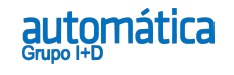

- Librerías

In [1]:
!pip -q install CoolProp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 28.3 MB/s eta 0:00:00


In [2]:
import CoolProp.CoolProp as CP
from CoolProp.CoolProp import PropsSI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **Planta**

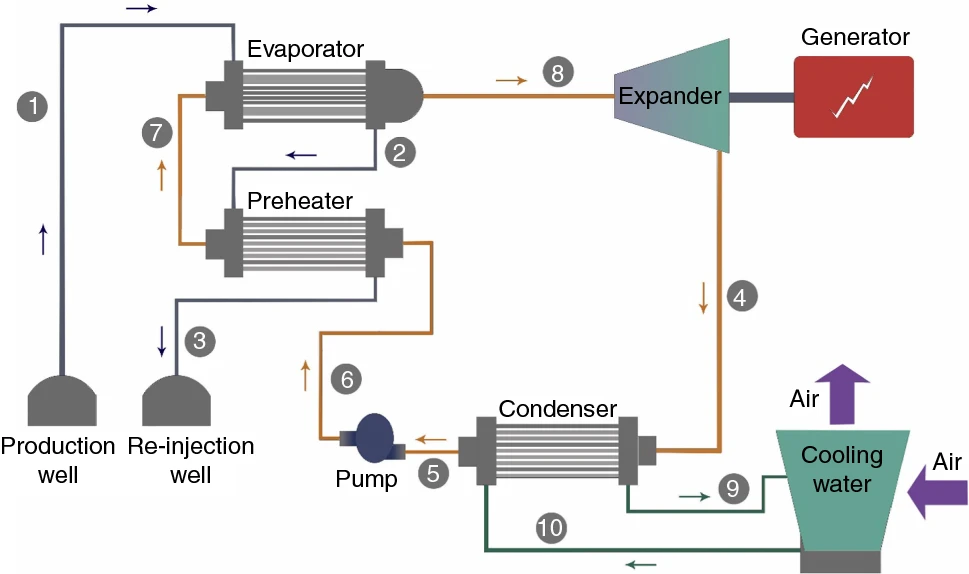

- Imagen tomada de https://doi.org/10.1016/j.renene.2019.12.034


- Datos reales de la planta:

In [3]:
CP.set_reference_state('R134a', 'ASHRAE')
# Definimos los fluidos
WF = CP.AbstractState('HEOS', 'R134a')  # Working fluid (fluido de trabajo)
GF = CP.AbstractState("HEOS", "Water")  # Geothermal fluid (fluido geotérmico)
CF = CP.AbstractState("HEOS", "Air")  # Air (Aire)

K = 273.15  # De celsius a kelvin

# Datos de operación
mdot_geo = 81  # Flujo másico del geofluido
mdot_wf = 94.37  # Flujo másico del fluido de trabajo
mdot_air = 8580  # Flujo másico del aire
mdot_cw = 596.6  # Flujo másico del fluido regrigerante
# El numero de cada presión y temperatura hace referencia al estado de la planta
T1 = 121 + K
T2 = 79 + K
T3 = 54.8 + K
T4 = 39.8 + K
T5 = 13 + K
T6 = 14.2 + K
T7 = 71.6 + K
T8 = 97 + K
T9 = 15 + K
T10 = 7 + K
T0 = 5 + K
P0 = 101.32e3
P1 = 240e3
P2 = P1
P3 = P1
P4 = 537.5e3
P5 = P4
P8 = 2503e3
P6 = P8
P7 = P8
P9 = 220e3
P10 = P9

# Datos de las máquinas
n_pump = 0.8  # Eficiencia isentrópica de la bomba
n_exp = 0.85  # Eficiencia isentrópica del expansor

- Se calculan los estados:



In [24]:
GF.update(CP.PT_INPUTS, P1, T1)
h1 = GF.hmass()
s1 = GF.smass()
GF.update(CP.PT_INPUTS, P2, T2)
h2 = GF.hmass()
s2 = GF.smass()
GF.update(CP.PT_INPUTS, P3, T3)
h3 = GF.hmass()
s3 = GF.smass()
WF.update(CP.PT_INPUTS, P4, T4)
h4 = WF.hmass()
s4 = WF.smass()
WF.update(CP.PSmass_INPUTS, P4, s4)
h4s = WF.hmass()
WF.update(CP.PT_INPUTS, P5, T5)
h5 = WF.hmass()
s5 = WF.smass()
WF.update(CP.PT_INPUTS, P6, T6)
h6 = WF.hmass()
s6 = WF.smass()
WF.update(CP.PT_INPUTS, P7, T7)
h7 = WF.hmass()
s7 = WF.smass()
WF.update(CP.PT_INPUTS, P8, T8)
h8 = WF.hmass()
s8 = WF.smass()
GF.update(CP.PT_INPUTS, P9, T9)
h9 = GF.hmass()
s9 = GF.smass()
GF.update(CP.PT_INPUTS, P10, T10)
h10 = GF.hmass()
s10 = GF.smass()
print("ENTROPIAS Y ENTALPIAS EN CADA ESTADO\n")
for i in range(1, 11):
    print(f"h{i} = ", globals()[f"h{i}"] / 1e3)
    print(f"s{i} = ", globals()[f"s{i}"] / 1e3)

ENTROPIAS Y ENTALPIAS EN CADA ESTADO

h1 =  508.0849790894981
s1 =  1.538652348384042
h2 =  330.9695670060645
s2 =  1.063552636768185
h3 =  229.61056060204817
s3 =  0.7653613777228491
h4 =  281.5931115011547
s4 =  0.9928768733339922
h5 =  69.57676866146579
s5 =  0.2670747793536632
h6 =  71.53115824462992
s6 =  0.2684218765118941
h7 =  158.45329209671863
s7 =  0.5431675353427164
h8 =  310.4456402961396
s8 =  0.9746102836795846
h9 =  63.190442489908925
s9 =  0.2244303943591524
h10 =  29.64267033761357
s10 =  0.10635819915241611


- Se calculan las exergías:

In [27]:
h0 = PropsSI("H", "T", T0, "P", P0, "water")
s0 = PropsSI("S", "T", T0, "P", P0, "water")
X1 = mdot_geo*(h1 - h0 - T0 * (s1 - s0))
X2 = mdot_geo*(h2 - h0 - T0 * (s2 - s0))
X3 = mdot_geo*(h3 - h0 - T0 * (s3 - s0))
X9 = mdot_cw*(h9 - h0 - T0 * (s9 - s0))
X10 = mdot_cw*(h10 - h0 - T0 * (s10 - s0))
h0 = PropsSI("H", "T", T0, "P", P0, "R134a")
s0 = PropsSI("S", "T", T0, "P", P0, "R134a")
X4 = mdot_wf*(h4 - h0 - T0 * (s4 - s0))
X5 = mdot_wf*(h5 - h0 - T0 * (s5 - s0))
X6 = mdot_wf*(h6 - h0 - T0 * (s6 - s0))
X7 = mdot_wf*(h7 - h0 - T0 * (s7 - s0))
X8 = mdot_wf*(h8 - h0 - T0 * (s8 - s0))

print("EXERGÍA EN CADA ESTADO\n")
for i in range(1,11):
    print(f"X{i} = ", globals()[f"X{i}"]/1e3)

EXERGÍA EN CADA ESTADO

X1 =  6496.073503013718
X2 =  2853.7928919175984
X3 =  1362.0071681725487
X4 =  3489.3143743656497
X5 =  2532.9225154063224
X6 =  2681.9982861831118
X7 =  3673.0370005967566
X8 =  6691.607511719063
X9 =  509.9368227948686
X10 =  88.7425590587137


## **Aplicación de ecuaciones de energía, exergía y eficiencias**

- Evaporador:

In [6]:
# Energia
Qdot_evap = mdot_geo * (h1 - h2)
print("Qdot_evap = ", Qdot_evap/1e3)
# Exergia
XDdot_evap = (X1 - X2) + (X7 - X8)
print("XDdot_evap =", XDdot_evap/1e3)
# Eficiencia exergetica
e_evap = (X8 - X7)/(X1 - X2)
print("e_evap = ", e_evap)

Qdot_evap =  14346.34837875812
XDdot_evap = 623.7100999738141
e_evap =  0.8287583614305564


- Precalentador:

In [7]:
# Energia
Qdot_preh = mdot_geo * (h2 - h3)
print("Qdot_preh = ", Qdot_preh/1e3)
# Exergia
XDdot_preh = (X6 - X7) + (X2 - X3)
print("XDdot_preh =", XDdot_preh/1e3)
# Eficiencia exergetica
e_preh = (X7 - X6)/(X2 - X3)
print("e_preh = ", e_preh)

Qdot_preh =  8210.079518725324
XDdot_preh = 500.7470093314049
e_preh =  0.6643304722917539


- Condensador:

In [8]:
# Energia
Qdot_cond = mdot_cw * (h9 - h10)
print("Qdot_cond = ", Qdot_cond/1e3)
# Exergia
XDdot_cond = (X4 - X5) + (X10 - X9)
print("XDdot_cond =", XDdot_cond/1e3)
# Eficiencia exergetica
e_cond = (X9 - X10)/(X4 - X5)
print("e_cond = ", e_cond)

Qdot_cond =  20014.600866059413
XDdot_cond = 535.1975952231726
e_cond =  0.4403992566336421


- Expansor

In [9]:
# Energia
Wdot_exp = mdot_wf * (h8 - h4)
print("Wdot_exp = ", Wdot_exp/1e3)
# Exergia
XDdot_exp = (X8 - X4) - Wdot_exp
print("XDdot_exp =", XDdot_exp/1e3)
# Eficiencia exergetica
e_exp = (Wdot_exp)/(X8 - X4)
print("e_exp = ", e_exp)

Wdot_exp =  2722.8131423827267
XDdot_exp = 479.47999497068673
e_exp =  0.8502697990456425


- Bomba

In [10]:
# Energia
Wdot_pump = mdot_wf * (h6 - h5)
print("Wdot_pump = ", Wdot_pump/1e3)
# Exergia
XDdot_pump = Wdot_pump - (X6 - X5)
print("XDdot_pump =", XDdot_pump/1e3)
# Eficiencia exergetica
e_pump = (X6 - X5) / (Wdot_pump)
print("e_pump = ", e_pump)

Wdot_pump =  184.43574496319872
XDdot_pump = 35.35997418640909
e_pump =  0.8082802539525913


- Eficiencia del ciclo:

In [13]:
n_cycle = (Wdot_exp - Wdot_pump)/(mdot_geo*(h1-h3))*100
print("Eficiencia del ciclo =", n_cycle, "%")

Eficiencia del ciclo = 11.25345470903541 %


- Eficiencias exergéticas:

In [12]:
n_exerI = (Wdot_exp - Wdot_pump)/X1*100
print("Eficiencia exergética I del ciclo =", n_exerI, "%")
n_exerII = (Wdot_exp - Wdot_pump)/(mdot_geo*(h1 - h3 - T0*(s1-s3)))*100
print("Eficiencia exergética II del ciclo =", n_exerII, "%")

Eficiencia exergética I del ciclo = 39.0755645890075 %
Eficiencia exergética II del ciclo = 49.441850413840726 %
